In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]
all_features = analysis_run["feature_universe"]

In [2]:
labels = ds.cells.fetch("clusters", key="I")
source = labels == "Ductal"
sink = np.isin(labels, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink labels must both be present")
source_sink_vector = np.zeros(len(labels), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()
float(source_sink_vector.sum())

6.418476861114186e-17

In [3]:
pseudotime_ref = ds.run_pseudotime_scoring(
    graph,
    ss_vec=source_sink_vector,
)
pseudotime = ds.load_pseudotime_scoring(pseudotime_ref)
{
    "artifact": pseudotime.ref,
    "graph": pseudotime.graph,
    "valid cells": int(pseudotime.valid.sum()),
}

{'artifact': ArtifactRef(assay='RNA', kind='pseudotime', artifact_id='f44aa3d857d2...'),
 'graph': ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='142b9a52613b...'),
 'valid cells': 3696}

<Axes: xlabel='umap_1', ylabel='umap_2'>

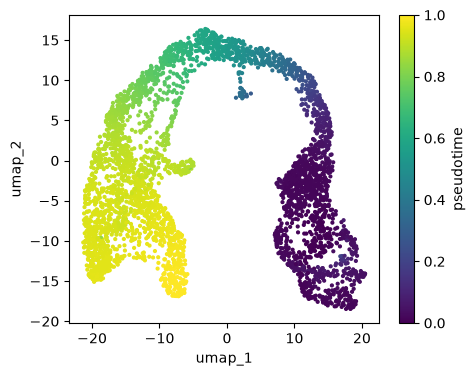

In [4]:
plot_data = analysis_run.cells.to_pandas_dataframe(["umap_1", "umap_2"])
plot_data["pseudotime"] = pseudotime.values
plot_data.loc[pseudotime.valid].plot.scatter(
    x="umap_1",
    y="umap_2",
    c="pseudotime",
    colormap="viridis",
    s=4,
    figsize=(5, 4),
)

In [5]:
pd.DataFrame(
    {
        "cluster": labels[pseudotime.valid],
        "pseudotime": pseudotime.values[pseudotime.valid],
    }
).groupby("cluster")["pseudotime"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
Alpha,481.0,0.944433,0.031305,0.325483,0.941341,0.948351,0.954650,0.966391
Beta,591.0,0.962389,0.024397,0.885668,0.944869,0.961238,0.983154,1.000000
Delta,70.0,0.896842,0.011002,0.872069,0.888724,0.897958,0.903287,0.931344
Ductal,916.0,0.019857,0.014621,0.000012,0.012388,0.015973,0.022485,0.105846
Epsilon,142.0,0.906567,0.030305,0.808831,0.894148,0.913521,0.931280,0.946040
Ngn3 high EP,642.0,0.472327,0.169853,0.078488,0.355909,0.516322,0.593001,0.740008
Ngn3 low EP,262.0,0.047391,0.036697,0.000000,0.019411,0.037693,0.068599,0.279896
Pre-endocrine,592.0,0.842567,0.066795,0.402827,0.790404,0.857373,0.900983,0.939593


In [6]:
marker_ref = ds.run_pseudotime_marker_search(
    pseudotime_ref,
    features=all_features,
)
markers = ds.load_pseudotime_markers(marker_ref)
markers.table[["p_value", "p_value_adjusted"]].notna().sum()

p_value             13821
p_value_adjusted    13821
dtype: int64

In [7]:
tested = markers.table.loc[
    markers.table["p_value_adjusted"].notna(),
    ["feature_name", "r_value", "p_value_adjusted"],
]
increasing = tested.loc[tested["r_value"] > 0].nlargest(10, "r_value")
decreasing = tested.loc[tested["r_value"] < 0].nsmallest(10, "r_value")
pd.concat({"increasing": increasing, "decreasing": decreasing})

feature_name   r_value  p_value_adjusted
increasing 14296         Gnas  0.739726               0.0
           23549          Cpe  0.733741               0.0
           21244        Aplp1  0.720802               0.0
           3186       Fam183b  0.673532               0.0
           25060        Hmgn3  0.636320               0.0
           26730       Pcsk1n  0.626743               0.0
           26573         Bex2  0.622786               0.0
           2189         Rap1b  0.605859               0.0
           5837          Scgn  0.601862               0.0
           4284           Ubb  0.592136               0.0
decreasing 24581        Rpl13 -0.825955               0.0
           18864         Spp1 -0.825855               0.0
           22385        Rps19 -0.817649               0.0
           16254         Rps8 -0.813255               0.0
           431            Dbi -0.793258               0.0
           19815        Rpl32 -0.788894               0.0
           26498        Rps4x -0.787990               0.0
           13425        Rpl12 -0.769085               0.0
           10164         Rps2 -0.755547               0.0
           10232       Rpl10a -0.749623               0.0